# RQ4: Feature Importance and Interpretability

Research question: Which features contribute most to recovery score prediction?

This notebook now runs the full RQ4 workflow directly: data loading, preprocessing, model fitting, evaluation, feature-importance analysis, permutation importance, and plot generation.

Project root: D:\UE Data Science Work\whoop-fitness-recovery-ml\Machine_Learning_Assignment
Dataset shape after loading: 100,000 rows x 41 columns
Modeling sample: 30,000 rows
Train/Test split: 24,000 train / 6,000 test


,user_id,date,day_of_week,age,gender,weight_kg,height_cm,fitness_level,primary_sport,recovery_score,...,max_heart_rate,activity_calories,hr_zone_1_min,hr_zone_2_min,hr_zone_3_min,hr_zone_4_min,hr_zone_5_min,workout_time_of_day,date_month,date_dayofyear
0,USER_00001,2023-01-01,Sunday,56,Female,53.9,167.2,Beginner,Weight Training,57.8,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1,1
1,USER_00001,2023-01-02,Monday,56,Female,53.9,167.2,Beginner,Weight Training,62.6,...,137.6,371.0,11.9,18.0,15.9,11.6,4.6,Evening,1,2
2,USER_00001,2023-01-03,Tuesday,56,Female,53.9,167.2,Beginner,Weight Training,81.5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1,3
3,USER_00001,2023-01-04,Wednesday,56,Female,53.9,167.2,Beginner,Weight Training,55.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,1,4
4,USER_00001,2023-01-05,Thursday,56,Female,53.9,167.2,Beginner,Weight Training,62.5,...,152.8,623.0,3.7,6.0,13.7,18.6,9.0,Evening,1,5


,Metric,Value
0,MAE,11.288673
1,RMSE,14.047146
2,R2,0.365772
3,Train Rows,24000.000000
4,Test Rows,6000.000000


,Rank,Original_Feature,Importance,Importance_Percent
0,1,resting_heart_rate,0.183481,18.348066
1,2,hrv,0.159803,15.980279
2,3,rhr_baseline,0.128287,12.828716
3,4,day_strain,0.099890,9.988994
4,5,hrv_baseline,0.086579,8.657902
5,6,calories_burned,0.047224,4.722385
6,7,date_dayofyear,0.046141,4.614092
7,8,height_cm,0.032441,3.244100
8,9,age,0.029622,2.962202
9,10,activity_strain,0.027517,2.751719


,Feature,Mean_R2_Decrease,Std_R2_Decrease
0,resting_heart_rate,0.468358,0.024062
1,rhr_baseline,0.378372,0.008834
2,hrv,0.274587,0.009412
3,hrv_baseline,0.161871,0.004993
4,day_strain,0.114160,0.006026
5,calories_burned,0.034618,0.003414
6,activity_strain,0.026640,0.005308
7,age,0.023216,0.004913
8,date_dayofyear,0.015246,0.003872
9,height_cm,0.011774,0.001262


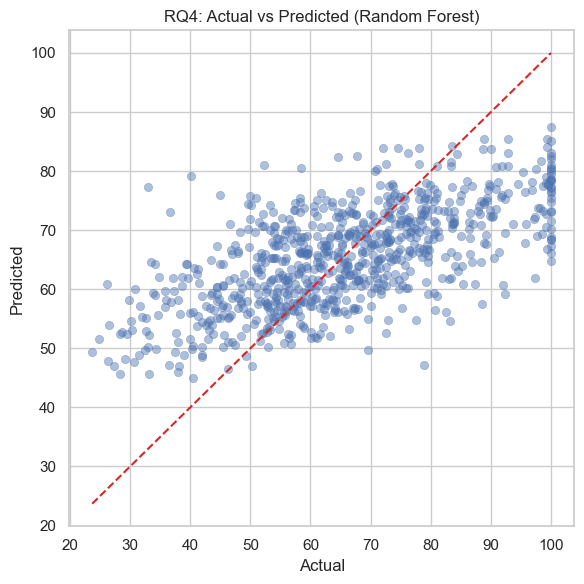

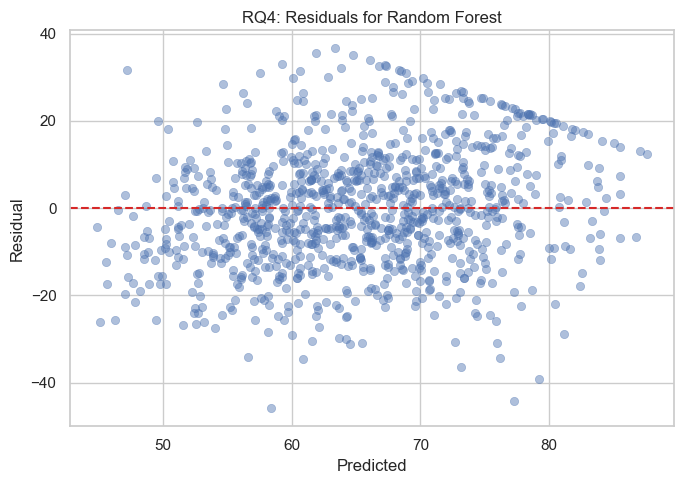

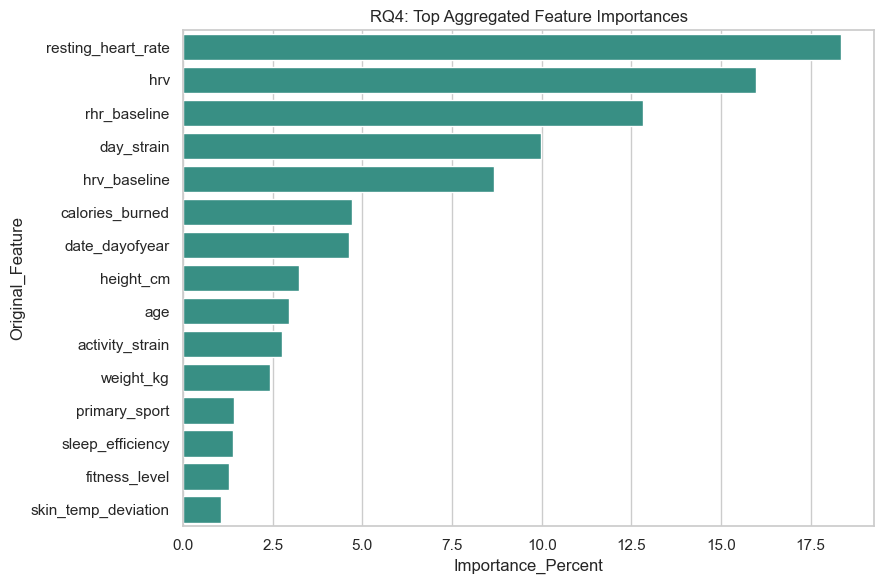

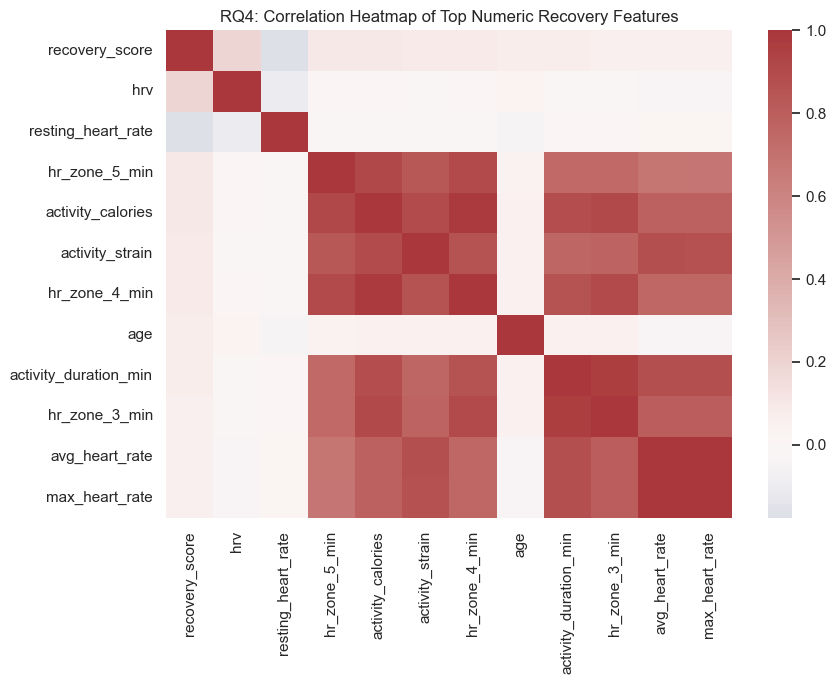

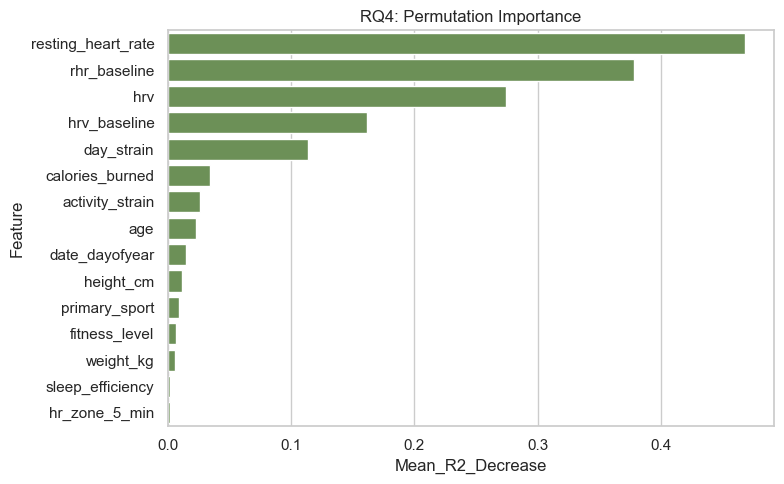

Saved tables:
- D:\UE Data Science Work\whoop-fitness-recovery-ml\Machine_Learning_Assignment\outputs\tables\RQ4_model_performance.csv
- D:\UE Data Science Work\whoop-fitness-recovery-ml\Machine_Learning_Assignment\outputs\tables\RQ4_feature_importance.csv
- D:\UE Data Science Work\whoop-fitness-recovery-ml\Machine_Learning_Assignment\outputs\tables\RQ4_aggregated_feature_importance.csv
- D:\UE Data Science Work\whoop-fitness-recovery-ml\Machine_Learning_Assignment\outputs\tables\RQ4_expected_feature_check.csv
- D:\UE Data Science Work\whoop-fitness-recovery-ml\Machine_Learning_Assignment\outputs\tables\RQ4_predictions_table.csv
- D:\UE Data Science Work\whoop-fitness-recovery-ml\Machine_Learning_Assignment\outputs\tables\RQ4_permutation_importance.csv
Saved figures:
- D:\UE Data Science Work\whoop-fitness-recovery-ml\Machine_Learning_Assignment\outputs\figures\images\RQ4_actual_vs_predicted.png
- D:\UE Data Science Work\whoop-fitness-recovery-ml\Machine_Learning_Assignment\outputs\fig

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents]

    assignment_dir = cwd / 'Machine_Learning_Assignment'
    if assignment_dir.exists():
        candidates.insert(1, assignment_dir.resolve())

    for candidate in candidates:
        if (candidate / 'whoop_assignment_pipeline.py').exists():
            return candidate

    raise FileNotFoundError(
        'Could not locate Machine_Learning_Assignment/whoop_assignment_pipeline.py from the current working directory.'
    )


def encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


def load_data(data_path: Path) -> pd.DataFrame:
    if not data_path.exists():
        raise FileNotFoundError(f'Dataset not found: {data_path}')

    df = pd.read_csv(data_path)
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['date_month'] = df['date'].dt.month
    df['date_dayofyear'] = df['date'].dt.dayofyear
    return df


def modelling_data(df: pd.DataFrame, target: str, sample_size: int = 30000) -> tuple[pd.DataFrame, pd.Series]:
    if sample_size and len(df) > sample_size:
        df = df.sample(sample_size, random_state=42).reset_index(drop=True)

    drop_cols = ['user_id', 'date', target]
    X = df.drop(columns=[col for col in drop_cols if col in df.columns])
    y = df[target]
    return X, y


def columns_for(X: pd.DataFrame) -> tuple[list[str], list[str]]:
    categorical = X.select_dtypes(include=['object', 'category']).columns.tolist()
    numeric = [col for col in X.columns if col not in categorical]
    return numeric, categorical


def preprocessor_for(X: pd.DataFrame) -> ColumnTransformer:
    numeric, categorical = columns_for(X)
    transformers = [
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), numeric),
    ]

    if categorical:
        transformers.append(
            ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', encoder())]), categorical)
        )

    return ColumnTransformer(transformers=transformers, verbose_feature_names_out=False)


def build_pipeline(X: pd.DataFrame) -> Pipeline:
    return Pipeline([
        ('preprocessor', preprocessor_for(X)),
        ('model', RandomForestRegressor(
            n_estimators=100,
            max_depth=14,
            min_samples_leaf=20,
            random_state=42,
            n_jobs=-1,
        )),
    ])


def rmse(y_true: pd.Series, y_pred: np.ndarray) -> float:
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def original_feature_name(encoded_name: str, original_cols: list[str]) -> str:
    if encoded_name in original_cols:
        return encoded_name
    for col in original_cols:
        if encoded_name.startswith(f'{col}_'):
            return col
    return encoded_name


def sampled(df: pd.DataFrame, size: int) -> pd.DataFrame:
    if len(df) <= size:
        return df
    return df.sample(size, random_state=42)


def save_figure(fig: plt.Figure, output_path: Path) -> None:
    fig.tight_layout()
    fig.savefig(output_path, dpi=200, bbox_inches='tight')


ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_PATH = ROOT / 'data' / 'whoop_fitness_dataset_100k.csv'
TABLE_DIR = ROOT / 'outputs' / 'tables'
IMAGE_DIR = ROOT / 'outputs' / 'figures' / 'images'
TARGET = 'recovery_score'

TABLE_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid')

raw_df = load_data(DATA_PATH)
X, y = modelling_data(raw_df, TARGET, sample_size=30000)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipe = build_pipeline(X)
pipe.fit(X_train, y_train)
preds = pipe.predict(X_test)

performance = pd.DataFrame([
    {'Metric': 'MAE', 'Value': mean_absolute_error(y_test, preds)},
    {'Metric': 'RMSE', 'Value': rmse(y_test, preds)},
    {'Metric': 'R2', 'Value': r2_score(y_test, preds)},
    {'Metric': 'Train Rows', 'Value': len(X_train)},
    {'Metric': 'Test Rows', 'Value': len(X_test)},
])

preprocessor = pipe.named_steps['preprocessor']
model = pipe.named_steps['model']
encoded_names = preprocessor.get_feature_names_out()

feature_df = pd.DataFrame({
    'Feature': encoded_names,
    'Importance': model.feature_importances_,
}).sort_values('Importance', ascending=False).reset_index(drop=True)
feature_df.insert(0, 'Rank', np.arange(1, len(feature_df) + 1))
feature_df['Importance_Percent'] = feature_df['Importance'] * 100
feature_df['Original_Feature'] = feature_df['Feature'].map(lambda name: original_feature_name(name, X.columns.tolist()))

agg = feature_df.groupby('Original_Feature', as_index=False)['Importance'].sum().sort_values('Importance', ascending=False).reset_index(drop=True)
agg.insert(0, 'Rank', np.arange(1, len(agg) + 1))
agg['Importance_Percent'] = agg['Importance'] * 100

expected = agg[agg['Original_Feature'].isin(['hrv', 'resting_heart_rate', 'sleep_hours', 'day_strain', 'sleep_efficiency', 'calories_burned'])].copy()

pred_table = X_test.copy()
pred_table['Actual_Recovery_Score'] = y_test.values
pred_table['Predicted_Recovery_Score'] = preds
pred_table['Residual'] = pred_table['Actual_Recovery_Score'] - pred_table['Predicted_Recovery_Score']
pred_table['Absolute_Error'] = pred_table['Residual'].abs()

numeric_corr = raw_df.select_dtypes(include=[np.number]).corr(numeric_only=True)
top_numeric = numeric_corr[TARGET].abs().sort_values(ascending=False).head(12).index.tolist()

perm_X = X_test.sample(min(1000, len(X_test)), random_state=42)
perm_y = y_test.loc[perm_X.index]
perm = permutation_importance(pipe, perm_X, perm_y, n_repeats=5, random_state=42, scoring='r2')
perm_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean_R2_Decrease': perm.importances_mean,
    'Std_R2_Decrease': perm.importances_std,
}).sort_values('Mean_R2_Decrease', ascending=False).reset_index(drop=True)

performance.to_csv(TABLE_DIR / 'RQ4_model_performance.csv', index=False)
feature_df.to_csv(TABLE_DIR / 'RQ4_feature_importance.csv', index=False)
agg.to_csv(TABLE_DIR / 'RQ4_aggregated_feature_importance.csv', index=False)
expected.to_csv(TABLE_DIR / 'RQ4_expected_feature_check.csv', index=False)
pred_table.head(2000).to_csv(TABLE_DIR / 'RQ4_predictions_table.csv', index=False)
perm_df.to_csv(TABLE_DIR / 'RQ4_permutation_importance.csv', index=False)

print(f'Project root: {ROOT}')
print(f'Dataset shape after loading: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns')
print(f'Modeling sample: {len(X):,} rows')
print(f'Train/Test split: {len(X_train):,} train / {len(X_test):,} test')

display(raw_df.head())
display(performance)
display(agg.head(15))
display(perm_df.head(15))

actual_vs_pred = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': preds,
})

fig, ax = plt.subplots(figsize=(6, 6))
plot_df = sampled(actual_vs_pred, 800)
sns.scatterplot(data=plot_df, x='Actual', y='Predicted', alpha=0.45, edgecolor=None, ax=ax)
line_low = min(plot_df['Actual'].min(), plot_df['Predicted'].min())
line_high = max(plot_df['Actual'].max(), plot_df['Predicted'].max())
ax.plot([line_low, line_high], [line_low, line_high], color='#d62828', linestyle='--')
ax.set_title('RQ4: Actual vs Predicted (Random Forest)')
save_figure(fig, IMAGE_DIR / 'RQ4_actual_vs_predicted.png')
display(fig)
plt.close(fig)

residual_df = pd.DataFrame({
    'Predicted': preds,
    'Residual': y_test.values - preds,
})

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(data=sampled(residual_df, 1000), x='Predicted', y='Residual', alpha=0.45, edgecolor=None, ax=ax)
ax.axhline(0, color='#d62828', linestyle='--')
ax.set_title('RQ4: Residuals for Random Forest')
save_figure(fig, IMAGE_DIR / 'RQ4_residuals.png')
display(fig)
plt.close(fig)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=agg.head(15), y='Original_Feature', x='Importance_Percent', color='#2a9d8f', ax=ax)
ax.set_title('RQ4: Top Aggregated Feature Importances')
save_figure(fig, IMAGE_DIR / 'RQ4_feature_importance_bar.png')
display(fig)
plt.close(fig)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(numeric_corr.loc[top_numeric, top_numeric], cmap='vlag', center=0, ax=ax)
ax.set_title('RQ4: Correlation Heatmap of Top Numeric Recovery Features')
save_figure(fig, IMAGE_DIR / 'RQ4_correlation_heatmap.png')
display(fig)
plt.close(fig)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=perm_df.head(15), y='Feature', x='Mean_R2_Decrease', color='#6a994e', ax=ax)
ax.set_title('RQ4: Permutation Importance')
save_figure(fig, IMAGE_DIR / 'RQ4_permutation_importance.png')
display(fig)
plt.close(fig)

print('Saved tables:')
for name in [
    'RQ4_model_performance.csv',
    'RQ4_feature_importance.csv',
    'RQ4_aggregated_feature_importance.csv',
    'RQ4_expected_feature_check.csv',
    'RQ4_predictions_table.csv',
    'RQ4_permutation_importance.csv',
]:
    print('-', TABLE_DIR / name)

print('Saved figures:')
for name in [
    'RQ4_actual_vs_predicted.png',
    'RQ4_residuals.png',
    'RQ4_feature_importance_bar.png',
    'RQ4_correlation_heatmap.png',
    'RQ4_permutation_importance.png',
]:
    print('-', IMAGE_DIR / name)
